In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
import os
import kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download("pratikshyakaggle/apple-inc-aapl-stock-5-years-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/pratikshyakaggle/apple-inc-aapl-stock-5-years-dataset


In [3]:
print(os.listdir(path))

['APPLE DATASET FOR 5 YEARS.xlsx.csv']


In [4]:
file_path = os.path.join(path, "APPLE DATASET FOR 5 YEARS.xlsx.csv")
print(file_path)

/kaggle/input/datasets/pratikshyakaggle/apple-inc-aapl-stock-5-years-dataset/APPLE DATASET FOR 5 YEARS.xlsx.csv


In [5]:
df = pd.read_csv(file_path, encoding="latin1")
print(df.head())

        Date    Open    High     Low  Close   Adj Close       Volume  \
0  17-Apr-26   267.1  272.30  266.72  271.13      271.13  31,696,705   
1  16-Apr-26   266.8  267.16  261.27  263.40      263.40  43,263,500   
2  15-Apr-26  258.16  266.56  257.81  266.43      266.43  49,913,500   
3  14-Apr-26  259.25  261.93  257.19  258.83      258.83  48,370,700   
4  13-Apr-26  259.73  260.18  256.66  259.20      259.20  36,234,700   

   Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12  \
0         NaN         NaN         NaN          NaN          NaN          NaN   
1         NaN         NaN         NaN          NaN          NaN          NaN   
2         NaN         NaN         NaN          NaN          NaN          NaN   
3         NaN         NaN         NaN          NaN          NaN          NaN   
4         NaN         NaN         NaN          NaN          NaN          NaN   

   Unnamed: 13  Unnamed: 14  
0          NaN          NaN  
1          NaN          Na

In [6]:
print(df.columns)
print(df.shape)

Index(['Date', 'Open', 'High', 'Low', 'Close ', 'Adj Close ', 'Volume',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14'],
      dtype='object')
(1276, 15)


In [7]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
print(df.columns)
print(df.head())

Index(['Date', 'Open', 'High', 'Low', 'Close ', 'Adj Close ', 'Volume'], dtype='object')
        Date    Open    High     Low  Close   Adj Close       Volume
0  17-Apr-26   267.1  272.30  266.72  271.13      271.13  31,696,705
1  16-Apr-26   266.8  267.16  261.27  263.40      263.40  43,263,500
2  15-Apr-26  258.16  266.56  257.81  266.43      266.43  49,913,500
3  14-Apr-26  259.25  261.93  257.19  258.83      258.83  48,370,700
4  13-Apr-26  259.73  260.18  256.66  259.20      259.20  36,234,700


In [8]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [9]:
df["Close"] = df["Close"].astype(str)
print(df[["Date", "Close"]].head(10))

        Date   Close
0  17-Apr-26  271.13
1  16-Apr-26   263.4
2  15-Apr-26  266.43
3  14-Apr-26  258.83
4  13-Apr-26   259.2
5  10-Apr-26  260.48
6   9-Apr-26  260.49
7   8-Apr-26   258.9
8   7-Apr-26   253.5
9   6-Apr-26  258.86


In [10]:
dividend_df = df[df["Close"].str.contains("Dividend", na=False)].copy()
stock_df = df[~df["Close"].str.contains("Dividend", na=False)].copy()

print("Dividend rows:", dividend_df.shape)
print("Stock rows:", stock_df.shape)

Dividend rows: (0, 7)
Stock rows: (1276, 7)


In [11]:
stock_df = df.copy()

print(stock_df.head())
print(stock_df.columns)

        Date    Open    High     Low   Close  Adj Close      Volume
0  17-Apr-26   267.1  272.30  266.72  271.13     271.13  31,696,705
1  16-Apr-26   266.8  267.16  261.27   263.4     263.40  43,263,500
2  15-Apr-26  258.16  266.56  257.81  266.43     266.43  49,913,500
3  14-Apr-26  259.25  261.93  257.19  258.83     258.83  48,370,700
4  13-Apr-26  259.73  260.18  256.66   259.2     259.20  36,234,700
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [12]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"], format="%d-%b-%y", errors="coerce")
print(stock_df[["Date"]].head())

        Date
0 2026-04-17
1 2026-04-16
2 2026-04-15
3 2026-04-14
4 2026-04-13


In [13]:
stock_df["Volume"] = stock_df["Volume"].astype(str).str.replace(",", "", regex=False)
stock_df["Volume"] = pd.to_numeric(stock_df["Volume"], errors="coerce")

print(stock_df[["Volume"]].head())

       Volume
0  31696705.0
1  43263500.0
2  49913500.0
3  48370700.0
4  36234700.0


In [14]:
import pandas as pd
price_cols = ["Open", "High", "Low", "Close", "Adj Close"]

for col in price_cols:
    stock_df[col] = pd.to_numeric(stock_df[col], errors="coerce")

print(stock_df[price_cols].head())

     Open    High     Low   Close  Adj Close
0  267.10  272.30  266.72  271.13     271.13
1  266.80  267.16  261.27  263.40     263.40
2  258.16  266.56  257.81  266.43     266.43
3  259.25  261.93  257.19  258.83     258.83
4  259.73  260.18  256.66  259.20     259.20


In [15]:
stock_df = stock_df.dropna(subset=["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"])
stock_df = stock_df.sort_values("Date")

print(stock_df.head())
print(stock_df.info())

           Date    Open    High     Low   Close  Adj Close      Volume
1275 2021-04-19  133.51  135.47  133.34  134.84     131.33  94264200.0
1274 2021-04-20  135.02  135.53  131.81  133.11     129.65  94812300.0
1273 2021-04-21  132.36  133.75  131.30  133.50     130.03  68847100.0
1272 2021-04-22  133.04  134.15  131.41  131.94     128.51  84566500.0
1271 2021-04-23  132.16  135.12  132.16  134.32     130.83  78657500.0
<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 1275 to 0
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1256 non-null   datetime64[ns]
 1   Open       1256 non-null   float64       
 2   High       1256 non-null   float64       
 3   Low        1256 non-null   float64       
 4   Close      1256 non-null   float64       
 5   Adj Close  1256 non-null   float64       
 6   Volume     1256 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage

In [16]:
stock_df.to_csv("clean_stock_data.csv", index=False)
print("Clean stock data saved successfully")

Clean stock data saved successfully


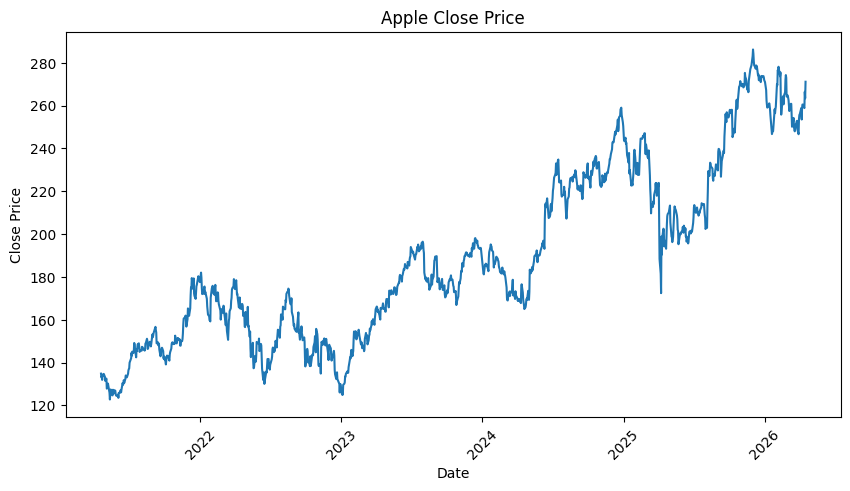

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(stock_df["Date"], stock_df["Close"])
plt.title("Apple Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()

In [18]:
stock_df["Days"] = (stock_df["Date"] - stock_df["Date"].min()).dt.days
print(stock_df[["Date", "Days", "Close"]].head())

           Date  Days   Close
1275 2021-04-19     0  134.84
1274 2021-04-20     1  133.11
1273 2021-04-21     2  133.50
1272 2021-04-22     3  131.94
1271 2021-04-23     4  134.32


In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
X = stock_df[["Days"]]
y = stock_df["Close"]

model = LinearRegression()
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [21]:
future_dates = pd.date_range(start="2027-01-01", end="2027-12-31", freq="MS")
future_days = (future_dates - stock_df["Date"].min()).days

future_df = pd.DataFrame({
    "Date": future_dates,
    "Days": future_days
})

future_df["Predicted_Close"] = model.predict(future_df[["Days"]])

print(future_df)

         Date  Days  Predicted_Close
0  2027-01-01  2083       270.605522
1  2027-02-01  2114       272.758520
2  2027-03-01  2142       274.703162
3  2027-04-01  2173       276.856159
4  2027-05-01  2203       278.939705
5  2027-06-01  2234       281.092702
6  2027-07-01  2264       283.176247
7  2027-08-01  2295       285.329244
8  2027-09-01  2326       287.482241
9  2027-10-01  2356       289.565787
10 2027-11-01  2387       291.718784
11 2027-12-01  2417       293.802330


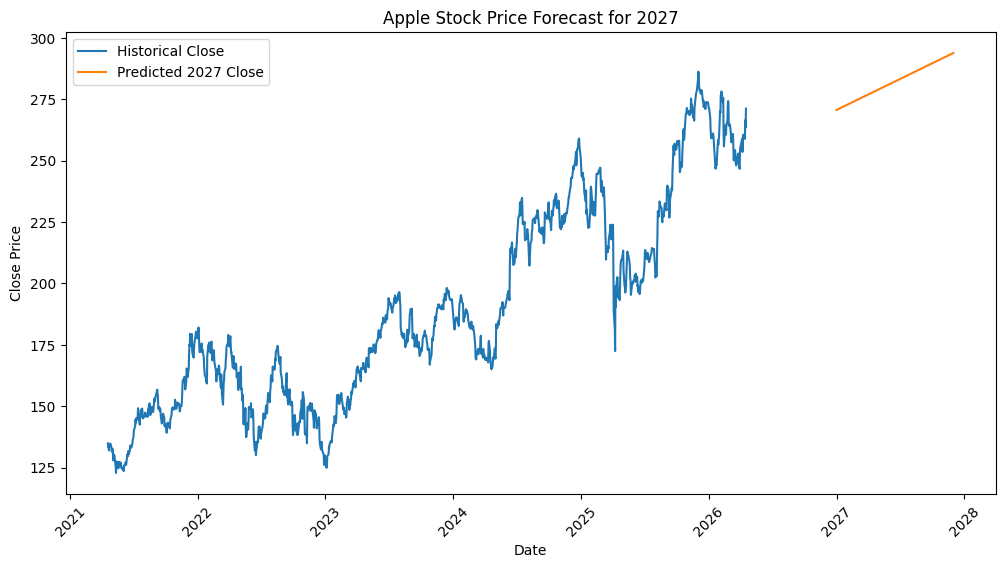

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(stock_df["Date"], stock_df["Close"], label="Historical Close")
plt.plot(future_df["Date"], future_df["Predicted_Close"], label="Predicted 2027 Close")
plt.title("Apple Stock Price Forecast for 2027")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [23]:
future_df.to_csv("apple_2027_forecast.csv", index=False)
print("Forecast saved successfully")

Forecast saved successfully


## Forecast Insights

1. Historical Apple stock closing prices were used to estimate 2027 prices.
2. A linear regression model was trained using time as the predictor.
3. The prediction shows the overall expected price trend for 2027.
4. This forecast is only an estimate based on historical trend.
5. More advanced time-series models can improve prediction accuracy.